In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
import networkx as nx
from collections import Counter

In [2]:
df = pd.read_csv("../data/sensors.csv")
df = df.rename(columns={
    'Timestamp': 'timestamp',
    'car-id':    'car_id',
    'car-type':  'car_type',
    'gate-name': 'gate_name',
})
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['car_id']  = df['car_id'].astype('string')
df['car_type']  = df['car_type'].astype('category')
df['gate_name'] = df['gate_name'].astype('category')

df = df.sort_values(['car_id', 'timestamp']).reset_index(drop=True)

# Временны́е признаки
df['date']        = df['timestamp'].dt.date
df['hour']        = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.day_name()       
df['day_of_week_n']= df['timestamp'].dt.dayofweek      
df['is_weekend']  = df['day_of_week_n'].isin([5, 6])
df['month']       = df['timestamp'].dt.month
df['week']        = df['timestamp'].dt.isocalendar().week.astype(int)

# Маршруты: следующие/предыдущие ворота 
df['prev_gate'] = df.groupby('car_id')['gate_name'].shift(1)
df['next_gate'] = df.groupby('car_id')['gate_name'].shift(-1)

# Время между событиями одной машины 
df['time_since_prev'] = (
    df.groupby('car_id')['timestamp']
      .diff()                          
)

# Порядковый номер визита машины
df['visit_order'] = df.groupby('car_id').cumcount() + 1

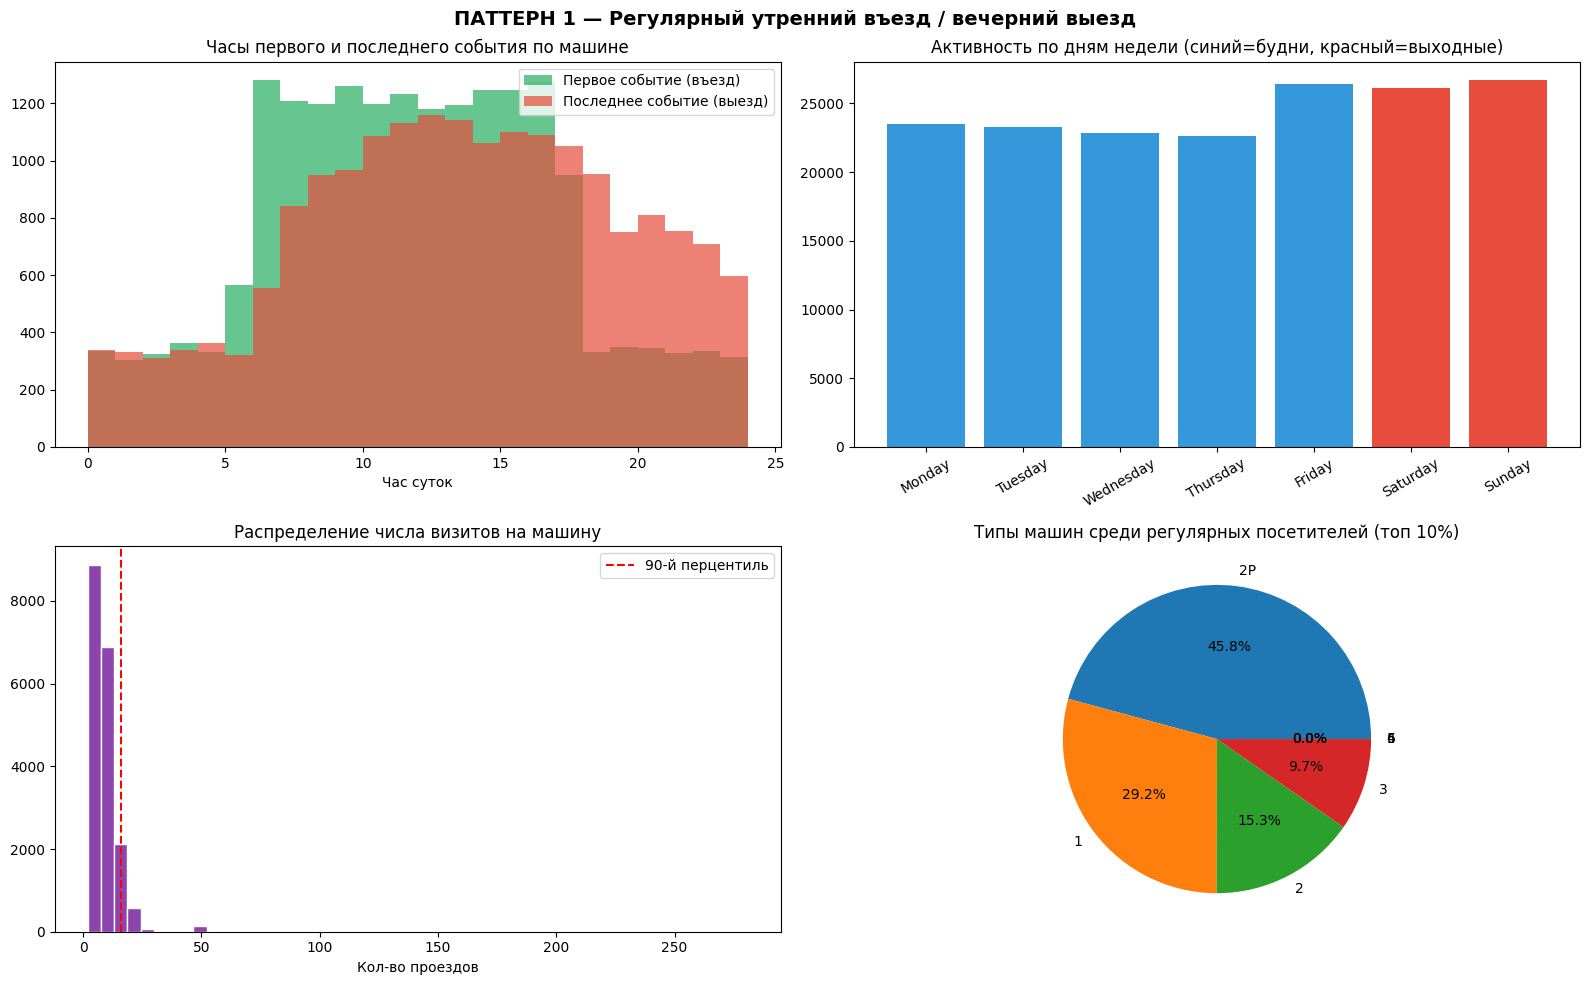

In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
# ПАТТЕРН 1: «Утренний въезд / вечерний выезд» — рабочий персонал
# Гипотеза: сотрудники парка въезжают утром через служебные ворота, 
#           выезжают вечером через те же или смежные
# ═══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('ПАТТЕРН 1 — Регулярный утренний въезд / вечерний выезд', fontsize=14, fontweight='bold')

# 1a. Распределение первого и последнего события машины по часам
first_events = df.groupby('car_id').first().reset_index()
last_events  = df.groupby('car_id').last().reset_index()

axes[0, 0].hist(first_events['hour'], bins=24, range=(0, 24),
                color='#27ae60', alpha=0.7, label='Первое событие (въезд)')
axes[0, 0].hist(last_events['hour'],  bins=24, range=(0, 24),
                color='#e74c3c', alpha=0.7, label='Последнее событие (выезд)')
axes[0, 0].set_title('Часы первого и последнего события по машине')
axes[0, 0].set_xlabel('Час суток')
axes[0, 0].legend()

# 1b. Распределение по дням недели — только будние?
daily_counts = df.groupby(['day_of_week', 'is_weekend']).size().reset_index(name='count')
days_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily_counts['day_of_week'] = pd.Categorical(daily_counts['day_of_week'], categories=days_order, ordered=True)
daily_counts = daily_counts.sort_values('day_of_week')

colors = ['#e74c3c' if w else '#3498db' for w in daily_counts['is_weekend']]
axes[0, 1].bar(daily_counts['day_of_week'], daily_counts['count'], color=colors)
axes[0, 1].set_title('Активность по дням недели (синий=будни, красный=выходные)')
axes[0, 1].tick_params(axis='x', rotation=30)

# 1c. Машины, у которых МНОГО визитов — регулярные посетители
visit_counts = df['car_id'].value_counts()
regular      = visit_counts[visit_counts >= visit_counts.quantile(0.9)]  # топ 10%

axes[1, 0].hist(visit_counts, bins=50, color='#8e44ad', edgecolor='white')
axes[1, 0].axvline(visit_counts.quantile(0.9), color='red', linestyle='--', label='90-й перцентиль')
axes[1, 0].set_title('Распределение числа визитов на машину')
axes[1, 0].set_xlabel('Кол-во проездов')
axes[1, 0].legend()

# 1d. Типы «регулярных» машин
regular_df = df[df['car_id'].isin(regular.index)]
regular_type = regular_df['car_type'].value_counts()
axes[1, 1].pie(regular_type.values, labels=regular_type.index,
               autopct='%1.1f%%', colors=sns.color_palette('tab10', len(regular_type)))
axes[1, 1].set_title('Типы машин среди регулярных посетителей (топ 10%)')

plt.tight_layout()
plt.savefig('pattern1_commuters.png', dpi=150)
plt.show()


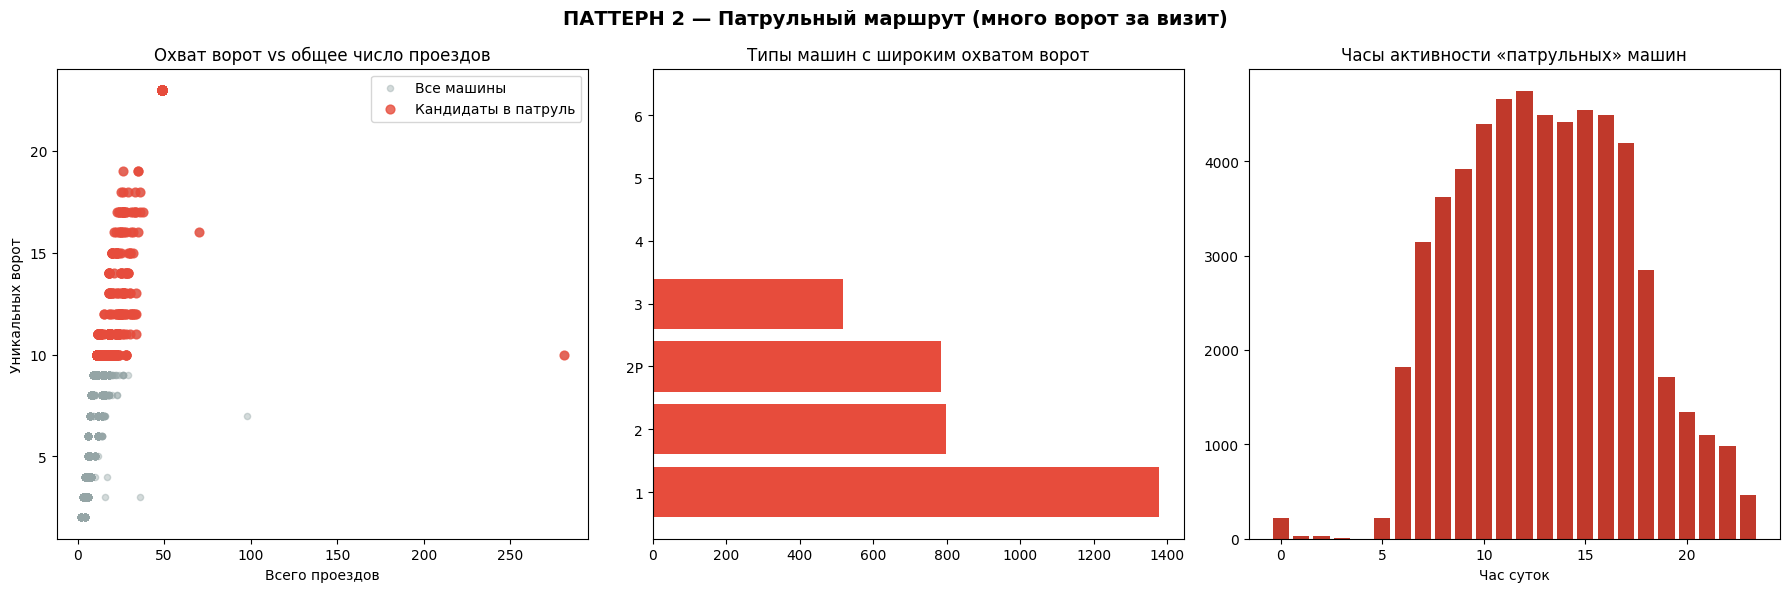

In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# ПАТТЕРН 2: «Патрульный маршрут» — машины, обходящие много ворот регулярно
# Гипотеза: охрана / рейнджеры объезжают периметр по кругу
# ═══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('ПАТТЕРН 2 — Патрульный маршрут (много ворот за визит)', fontsize=14, fontweight='bold')

# Машины с высоким числом уникальных ворот
gate_diversity = df.groupby('car_id').agg(
    unique_gates = ('gate_name', 'nunique'),
    total_visits = ('car_id',    'count'),
    car_type     = ('car_type',  lambda x: x.mode()[0])
).reset_index()

patrol_threshold = gate_diversity['unique_gates'].quantile(0.85)
patrol_cars = gate_diversity[gate_diversity['unique_gates'] >= patrol_threshold]

axes[0].scatter(gate_diversity['total_visits'], gate_diversity['unique_gates'],
                alpha=0.4, color='#95a5a6', s=20, label='Все машины')
axes[0].scatter(patrol_cars['total_visits'], patrol_cars['unique_gates'],
                alpha=0.8, color='#e74c3c', s=40, label='Кандидаты в патруль')
axes[0].set_xlabel('Всего проездов')
axes[0].set_ylabel('Уникальных ворот')
axes[0].set_title('Охват ворот vs общее число проездов')
axes[0].legend()

# Типы «патрульных» машин
patrol_types = patrol_cars['car_type'].value_counts()
axes[1].barh(patrol_types.index, patrol_types.values, color='#e74c3c')
axes[1].set_title('Типы машин с широким охватом ворот')

# В какие часы они активны?
patrol_hours = df[df['car_id'].isin(patrol_cars['car_id'])]['hour'].value_counts().sort_index()
axes[2].bar(patrol_hours.index, patrol_hours.values, color='#c0392b')
axes[2].set_title('Часы активности «патрульных» машин')
axes[2].set_xlabel('Час суток')

plt.tight_layout()
plt.savefig('pattern2_patrol.png', dpi=150)
plt.show()

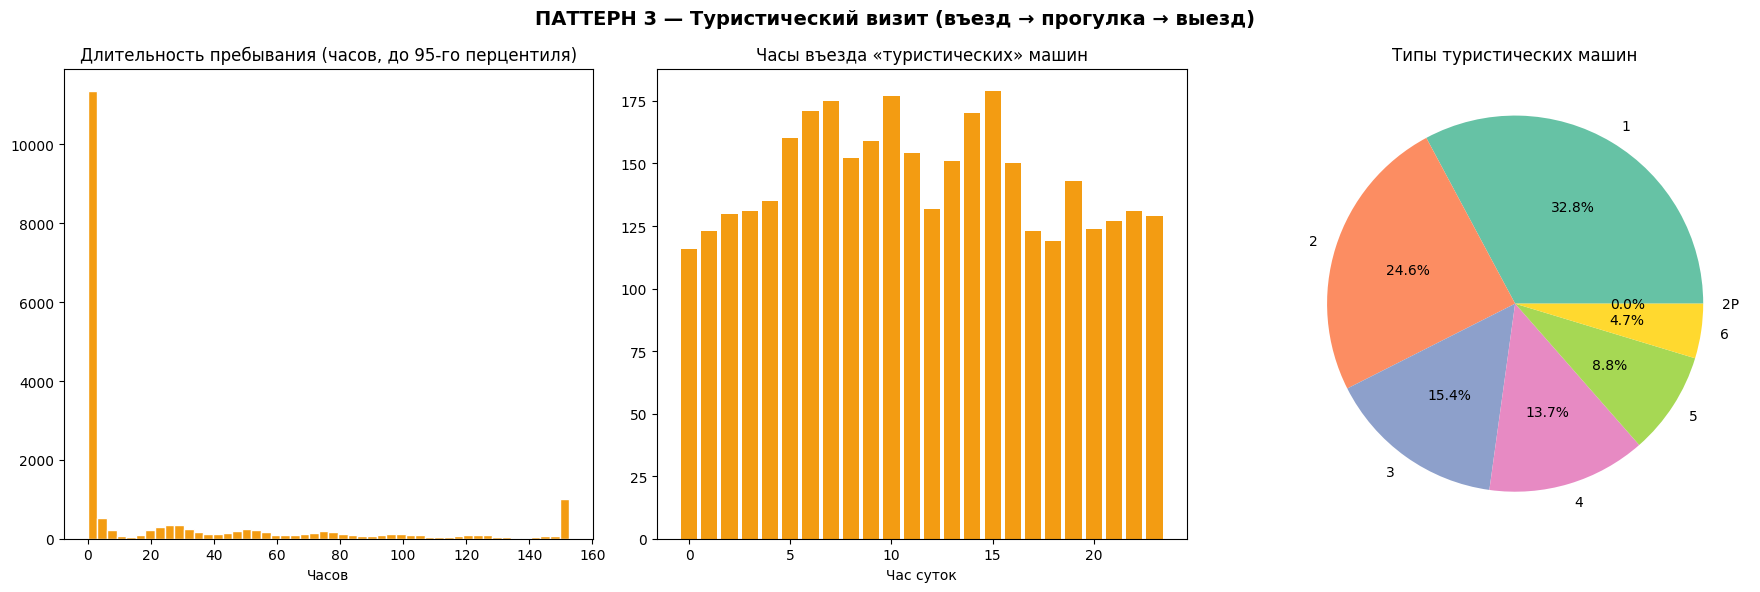

In [5]:

# ═══════════════════════════════════════════════════════════════════════════════
# ПАТТЕРН 3: «Туристический визит» — въезд → несколько внутренних точек → выезд
# Гипотеза: посетители/туристы, которые приезжают, гуляют и уезжают
# ═══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('ПАТТЕРН 3 — Туристический визит (въезд → прогулка → выезд)', fontsize=14, fontweight='bold')

# Продолжительность визита (время от первого до последнего события)
duration = df.groupby('car_id')['timestamp'].agg(['min', 'max'])
duration['duration_h'] = (duration['max'] - duration['min']).dt.total_seconds() / 3600

axes[0].hist(duration['duration_h'].clip(upper=duration['duration_h'].quantile(0.95)),
             bins=50, color='#f39c12', edgecolor='white')
axes[0].set_title('Длительность пребывания (часов, до 95-го перцентиля)')
axes[0].set_xlabel('Часов')

# Въезд по часам у «туристов» (1-3 события, <8 часов)
tourist_ids = df.groupby('car_id').filter(
    lambda g: (len(g) <= 5) and
              ((g['timestamp'].max() - g['timestamp'].min()).total_seconds() / 3600 < 8)
)['car_id'].unique()
tourist_df = df[df['car_id'].isin(tourist_ids)]

tourist_hours = tourist_df.groupby('car_id').first()['hour'].value_counts().sort_index()
axes[1].bar(tourist_hours.index, tourist_hours.values, color='#f39c12')
axes[1].set_title('Часы въезда «туристических» машин')
axes[1].set_xlabel('Час суток')

# Типы туристических машин
tourist_types = tourist_df['car_type'].value_counts()
axes[2].pie(tourist_types.values, labels=tourist_types.index,
            autopct='%1.1f%%', colors=sns.color_palette('Set2', len(tourist_types)))
axes[2].set_title('Типы туристических машин')

plt.tight_layout()
plt.savefig('pattern3_tourists.png', dpi=150)
plt.show()

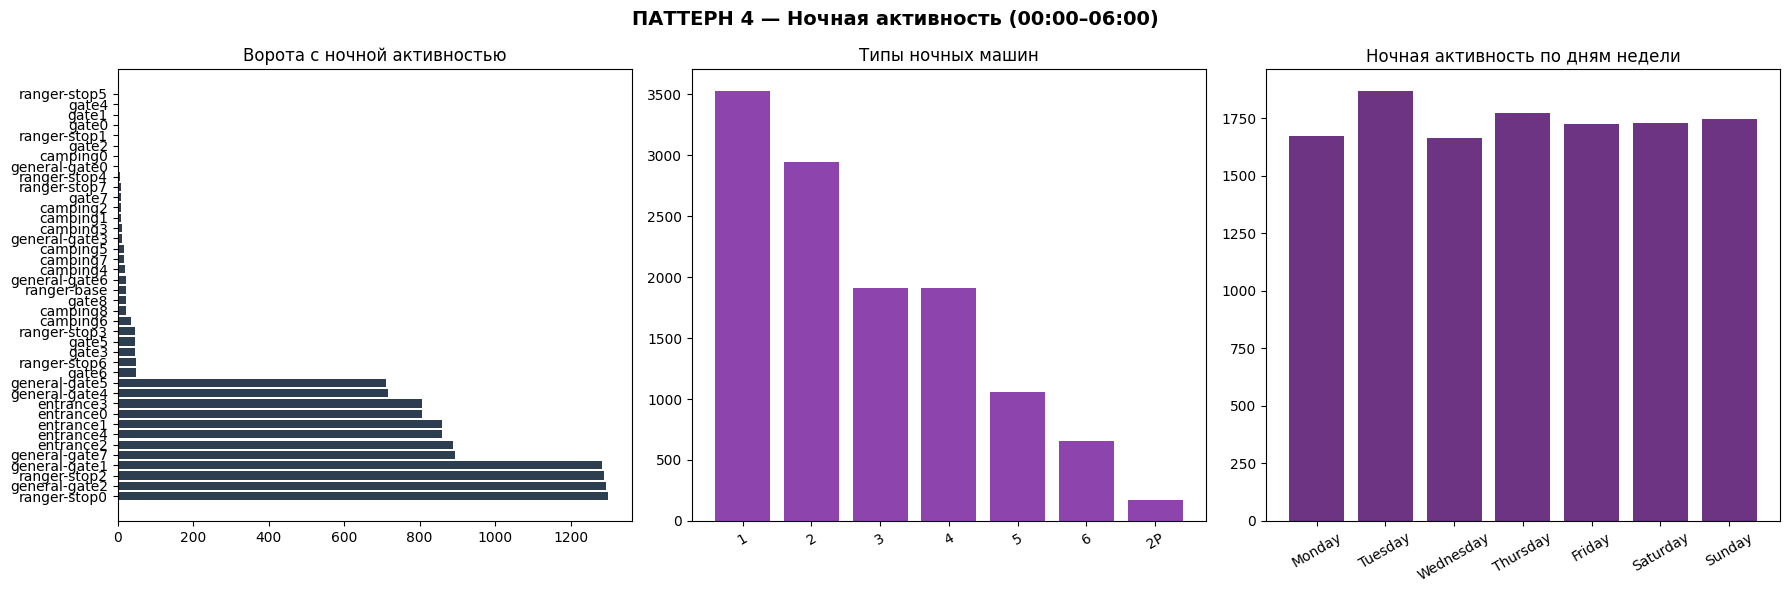

In [6]:


# ═══════════════════════════════════════════════════════════════════════════════
# ПАТТЕРН 4: «Ночная активность» — проезды в нетипичные часы
# Гипотеза: поставки / техническое обслуживание / нелегальная активность
# ═══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('ПАТТЕРН 4 — Ночная активность (00:00–06:00)', fontsize=14, fontweight='bold')

night_df = df[df['hour'].between(0, 5)]

# Ворота ночной активности
night_gates = night_df['gate_name'].value_counts()
axes[0].barh(night_gates.index, night_gates.values, color='#2c3e50')
axes[0].set_title('Ворота с ночной активностью')

# Типы ночных машин
night_types = night_df['car_type'].value_counts()
axes[1].bar(night_types.index, night_types.values, color='#8e44ad')
axes[1].set_title('Типы ночных машин')
axes[1].tick_params(axis='x', rotation=30)

# Ночная активность по дням недели
night_days = night_df['day_of_week'].value_counts().reindex(days_order)
axes[2].bar(night_days.index, night_days.values, color='#6c3483')
axes[2].set_title('Ночная активность по дням недели')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('pattern4_night.png', dpi=150)
plt.show()

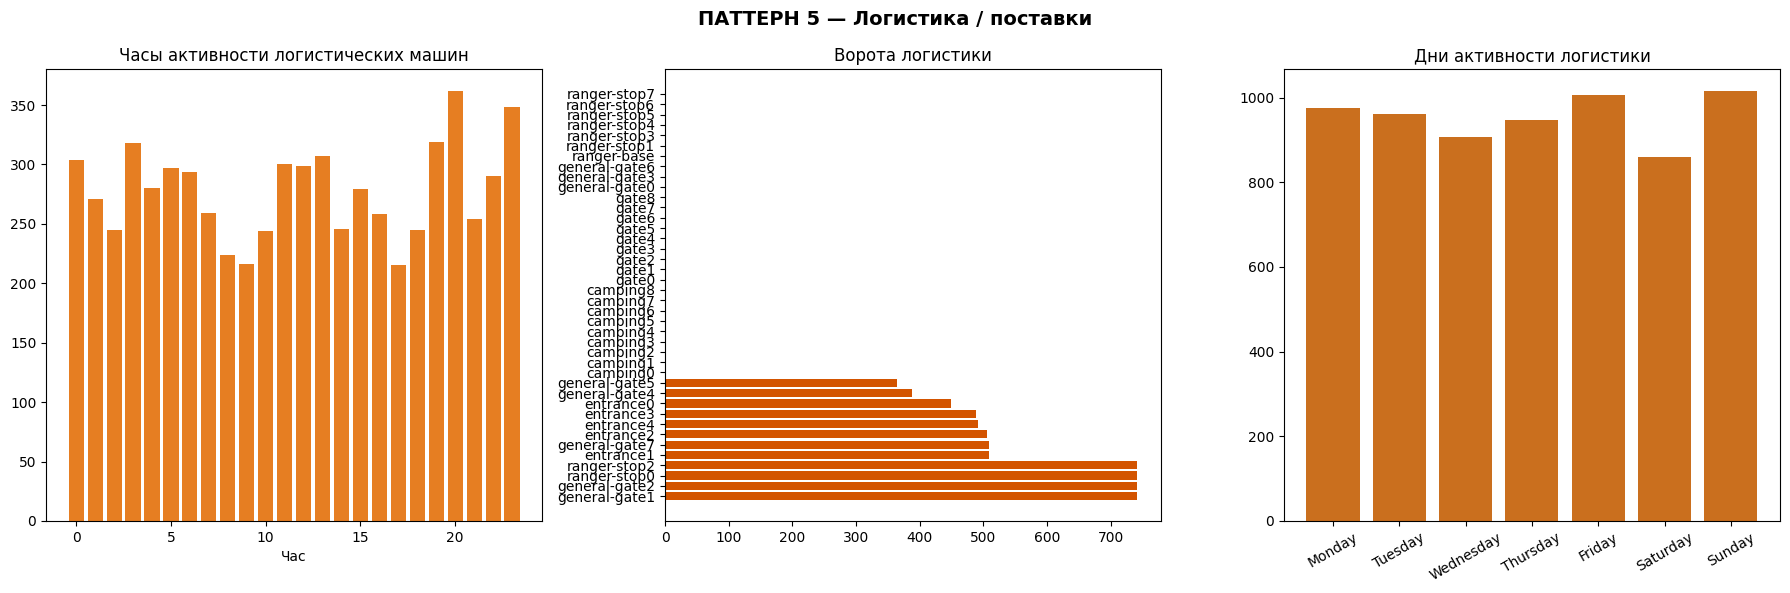

In [7]:

# ═══════════════════════════════════════════════════════════════════════════════
# ПАТТЕРН 5: «Логистика / поставки» — тяжёлые машины, специфические ворота
# Гипотеза: грузовики привозят снаряжение/еду/мусор в определённое время
# ═══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('ПАТТЕРН 5 — Логистика / поставки', fontsize=14, fontweight='bold')

# Замените '2W' и 'Truck' на реальные значения из вашего датасета
heavy_types = [t for t in df['car_type'].unique() 
               if any(kw in str(t).lower() for kw in ['truck','cargo','delivery','грузов','2axle','van'])]

if heavy_types:
    logistics_df = df[df['car_type'].isin(heavy_types)]
else:
    # fallback: нижние 20% по частоте типов — редкие/специфические
    rare_types = df['car_type'].value_counts().tail(int(df['car_type'].nunique() * 0.3)).index
    logistics_df = df[df['car_type'].isin(rare_types)]

log_hour = logistics_df['hour'].value_counts().sort_index()
axes[0].bar(log_hour.index, log_hour.values, color='#e67e22')
axes[0].set_title('Часы активности логистических машин')
axes[0].set_xlabel('Час')

log_gates = logistics_df['gate_name'].value_counts()
axes[1].barh(log_gates.index, log_gates.values, color='#d35400')
axes[1].set_title('Ворота логистики')

log_days = logistics_df['day_of_week'].value_counts().reindex(days_order)
axes[2].bar(log_days.index, log_days.values, color='#ca6f1e')
axes[2].set_title('Дни активности логистики')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('pattern5_logistics.png', dpi=150)
plt.show()


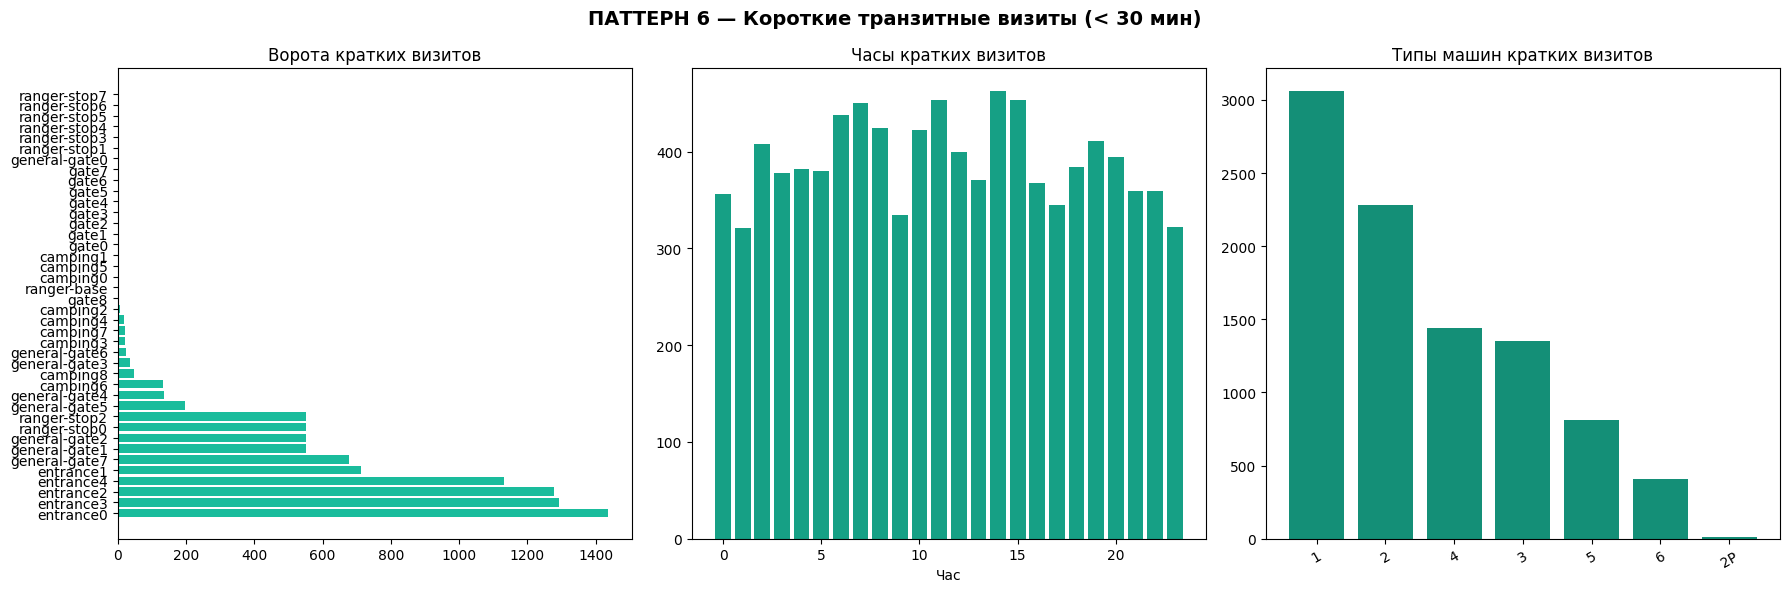

In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# ПАТТЕРН 6: «Короткая остановка» — машина появляется и быстро исчезает
# Гипотеза: курьеры, проверки КПП, транзитный трафик
# ═══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('ПАТТЕРН 6 — Короткие транзитные визиты (< 30 мин)', fontsize=14, fontweight='bold')

duration_reset = duration.reset_index()
short_visit = duration_reset[duration_reset['duration_h'] < 0.5]  # < 30 минут
short_df = df[df['car_id'].isin(short_visit['car_id'])]

short_gates = short_df['gate_name'].value_counts()
axes[0].barh(short_gates.index, short_gates.values, color='#1abc9c')
axes[0].set_title('Ворота кратких визитов')

short_hours = short_df['hour'].value_counts().sort_index()
axes[1].bar(short_hours.index, short_hours.values, color='#16a085')
axes[1].set_title('Часы кратких визитов')
axes[1].set_xlabel('Час')

short_types = short_df['car_type'].value_counts()
axes[2].bar(short_types.index, short_types.values, color='#148f77')
axes[2].set_title('Типы машин кратких визитов')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('pattern6_transit.png', dpi=150)
plt.show()